# TP N°1 Regresión Lineal y Polinómica
* Dado el conjunto de datos, plantear una regresión lineal (grado 1) y analizar si ese modelo es el óptimo para los datos dados.
* Luego plantear una regresión polinómica (defina el grado del polinomio que mejor se adpate a los datos)
* Realice para todos los casos, el grafi simultáneo de los datos y el modelo generado.
* Analizar resultados.  

## 1. Conjunto de Datos


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

creamos el conjunto de datos con números aleatorios, usando f(x)

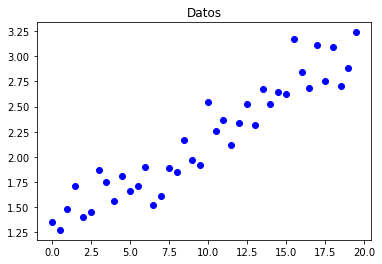

In [2]:
def f(x):  # función f(x) = 0.1*x + 1.25 + 0.2*Ruido_Gaussiano
    np.random.seed(42) # para poder reproducirlo
    y = 0.1*x + 1.25 + 0.2*np.random.randn(x.shape[0])
    return y

x = np.arange(0, 20, 0.5) # generamos valores x de 0 a 20 en intervalos de 0.5
y = f(x) # calculamos y a partir de la función que hemos generado

# hacemos un gráfico de los datos que hemos generado
plt.scatter(x,y,label='data', color='blue')
plt.title('Datos');

Dimensiones de los conjuntos x e y

In [3]:
print(f"Dimension eje y {y.shape}, tipo de dato: {type(y.shape)}")
print(y)
print(f"Dimension eje x {x.shape}, tipo de dato: {type(x.shape)}")
print(x)


Dimension eje y (40,), tipo de dato: <class 'tuple'>
[1.34934283 1.27234714 1.47953771 1.70460597 1.40316933 1.45317261
 1.86584256 1.75348695 1.55610512 1.80851201 1.65731646 1.70685405
 1.89839245 1.51734395 1.60501643 1.88754249 1.84743378 2.16284947
 1.96839518 1.91753926 2.54312975 2.25484474 2.36350564 2.11505036
 2.34112346 2.52218452 2.31980128 2.6751396  2.52987226 2.64166125
 2.62965868 3.17045564 2.84730056 2.68845781 3.11450898 2.75583127
 3.09177272 2.70806598 2.88436279 3.23937225]
Dimension eje x (40,), tipo de dato: <class 'tuple'>
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5]


## 2. Regresión Lineal
Importamos la clase de Regresión Lineal de scikit-learn y entrenamos el modelo con los datos.

In [4]:
from sklearn.linear_model import LinearRegression

regresion_lineal = LinearRegression()

x = x.reshape(-1,1)

regresion_lineal.fit(x,y)


LinearRegression()

In [5]:
# Predecimos los valores y para los datos usados en el entrenamiento
w, b = regresion_lineal.coef_[0], regresion_lineal.intercept_

y_pred_entrenamiento = regresion_lineal.predict(x)

## Función predictora
El resultado es obtener la función para predecir, dado valores 

In [10]:
print('------------------\nfunción del modelo\n------------------')
print ('f(x)= ',w,"x", "+" ,b)

------------------
función del modelo
------------------
f(x)=  0.0918352184351532 x + 1.2858792525736682


## Métricas de Evaluación para Modelos de Regresión
### MSE, Mean Squared Error

Es una medida estadística que se utiliza para evaluar qué tan bien un modelo predice o ajusta los datos. Es muy común en problemas de regresión y aprendizaje automático.
La fórmula del **Error Cuadrático Medio** es:
$$
ECM = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$
Donde:


- \( y_i \): valor real  
- \( \hat{y}_i \): valor predicho  
- \( n \): número total de observaciones

### Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error)
El RMSE es una de las métricas más utilizadas para medir la diferencia entre los valores predichos por un modelo y los valores reales. Representa la desviación estándar de los residuos (errores de predicción).

**Descripción Breve:**
El RMSE te dice, en promedio, cuánto se equivoca tu modelo en las unidades originales de la variable objetivo. Un valor más bajo indica un mejor ajuste del modelo a los datos. Es particularmente sensible a los errores grandes debido al término cuadrático, lo que significa que las predicciones muy erróneas lo penalizan fuertemente.

$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

Donde:
- n es el número total de observaciones.
- y_i​ es el valor real de la i-ésima observación.
- y^​i​ es el valor predicho por el modelo para la i-ésima observación.

### Coeficiente de Determinación (R²)

El Coeficiente de Determinación, o R² (R-cuadrado), mide la proporción de la varianza total de la variable dependiente que es explicada por el modelo.

**Descripción Breve:**
R² proporciona una medida de qué tan bien las predicciones del modelo se ajustan a los valores reales. Su valor varía entre 0 y 1 (aunque puede ser negativo para modelos muy malos). Un R² de 0.75, por ejemplo, significa que el modelo es capaz de explicar el 75% de la variabilidad de los datos. Un valor más cercano a 1 indica un mejor ajuste.

Fórmula:
$$ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $$
- ∑(yi​−y^​i​)2 es la Suma de los Cuadrados de los Residuos (variabilidad no explicada por el modelo).

- ∑(yi​−yˉ​)2 es la Suma Total de los Cuadrados (variabilidad total de los datos).

- yˉ​ es la media de los valores reales.

In [11]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true = y, y_pred = y_pred_entrenamiento)
# La raíz cuadrada del MSE es el RMSE
rmse = np.sqrt(mse)
print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
r2 = regresion_lineal.score(x, y)
print('Coeficiente de Determinación R2 = ' + str(r2))

Error Cuadrático Medio (MSE) = 0.03318522012927899
Raíz del Error Cuadrático Medio (RMSE) = 0.18216810952875093
Coeficiente de Determinación R2 = 0.8943593637683117


## Gráfico de la función encontrada

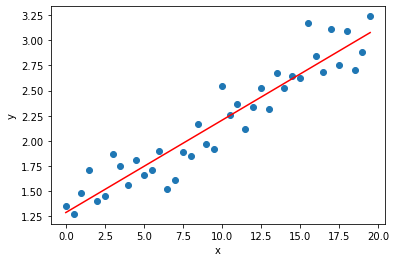

In [9]:
plt.scatter(x,y)
prediccion = regresion_lineal.predict(x.reshape(-1,1))
plt.plot(x,prediccion,'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 3. Regresión Polinómica
Ahora en el siguiente ejemplo se probará con otros datos para que se pueda apreciar más el uso de una regresióm polinómica. Según el grado del polinomio este se adaptará mejor a la curva que formen los datos. Prestar atención que a mayor grado puede parecer que la función obtenida va a ser más precisa. Pero encuanto se cambie de datos, puede fallar, esto da a lugar al overfitting.

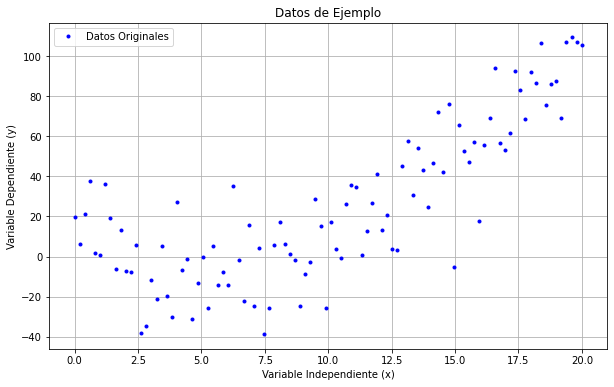

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Matplotlib en línea para Jupyter
%matplotlib inline

# Creemos datos de ejemplo con una relación cuadrática + ruido
np.random.seed(42) # Semilla para que los resultados sean reproducibles
x = np.linspace(0, 20, 100) # 100 puntos entre 0 y 20
y = 0.5 * x**2 - 5 * x + 10 + np.random.normal(0, 20, 100) # y = ax^2 + bx + c + ruido

# Convertimos x a un formato de columna para scikit-learn
x = x.reshape(-1, 1)

# Visualización inicial de los datos
plt.figure(figsize=(10, 6))
plt.plot(x, y, "b.", label="Datos Originales")
plt.xlabel("Variable Independiente (x)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Datos de Ejemplo")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def analizar_regresion_polinomica(degree, x, y):
    """
    Realiza una regresión polinómica del grado especificado,
    imprime los resultados y grafica la curva de ajuste.
    """
    # 1. Transformar las características a polinómicas
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    x_poly = poly_features.fit_transform(x)

    # 2. Entrenar el modelo de Regresión Lineal
    model = LinearRegression()
    model.fit(x_poly, y)

    # 3. Preparar datos para la gráfica de la curva
    # Creamos un rango de x más suave para una línea continua
    x_plot = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
    x_plot_poly = poly_features.transform(x_plot)
    y_plot = model.predict(x_plot_poly) # ¡Usamos predict() en lugar de la fórmula manual!

    # 4. Calcular el R²
    y_pred = model.predict(x_poly)
    r_sq = r2_score(y, y_pred)
    
    # 5. Imprimir resultados
    print(f"--- Análisis para Grado {degree} ---")
    print(f"Coeficientes (b_1, b_2, ...): {model.coef_}")
    print(f"Intercepto (b_0): {model.intercept_}")
    print(f"Coeficiente de Determinación (R²): {r_sq:.4f}\n")

    # 6. Devolver los puntos de la gráfica y el R² para comparación
    return x_plot, y_plot, r_sq

--- Análisis para Grado 1 ---
Coeficientes (b_1, b_2, ...): [5.13793267]
Intercepto (b_0): -26.45289007818055
Coeficiente de Determinación (R²): 0.6030

--- Análisis para Grado 2 ---
Coeficientes (b_1, b_2, ...): [-5.59509062  0.53665116]
Intercepto (b_0): 8.962472967995733
Coeficiente de Determinación (R²): 0.7819

--- Análisis para Grado 15 ---
Coeficientes (b_1, b_2, ...): [-2.19971306e-09 -1.85366157e-07 -9.41329487e-08 -5.07501397e-07
 -2.35443632e-06 -9.08231809e-06 -2.58917098e-05 -3.87898691e-05
  1.96533716e-05 -3.76713004e-06  3.88507840e-07 -2.37302611e-08
  8.64785521e-10 -1.74747472e-11  1.51363811e-13]
Intercepto (b_0): -1.3682860450064247
Coeficiente de Determinación (R²): 0.7742



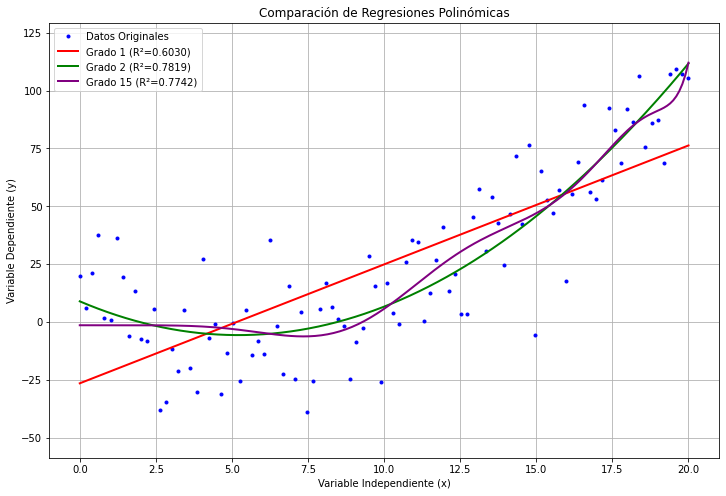

In [14]:
# Grados que queremos probar
grados = [1, 2, 15]
colores = ['red', 'green', 'purple']

plt.figure(figsize=(12, 8))
plt.plot(x, y, "b.", label="Datos Originales")

for i, degree in enumerate(grados):
    # Llamamos a nuestra función
    x_plot, y_plot, r_sq = analizar_regresion_polinomica(degree, x, y)
    
    # Añadimos la curva al gráfico
    plt.plot(x_plot, y_plot, color=colores[i], linewidth=2, label=f"Grado {degree} (R²={r_sq:.4f})")

plt.xlabel("Variable Independiente (x)")
plt.ylabel("Variable Dependiente (y)")
plt.title("Comparación de Regresiones Polinómicas")
plt.legend()
plt.grid(True)
plt.ylim(y.min() - 20, y.max() + 20) # Ajustar límites para mejor visualización
plt.show()